In [2]:
# ─────────────────────────────────────────────────────────────
# ▶ Install required packages
# ─────────────────────────────────────────────────────────────
!pip install --quiet networkx numpy matplotlib

# ─────────────────────────────────────────────────────────────
# ▶ Imports
# ─────────────────────────────────────────────────────────────
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import os


In [3]:
G = nx.Graph()
floors = 3
rooms_per_floor = 5
room_ids = {}

for f in range(floors):
    for r in range(rooms_per_floor):
        room_number = f"{(f + 1) * 100 + r + 1}"  # 101, 102, ..., 305
        room_type = random.choice(["ward", "ICU", "OR", "storage", "lobby"])
        G.add_node(
            room_number,
            type="room",
            floor=f,
            room_type=room_type,
            structural_integrity=round(random.uniform(0.3, 1.0), 2),
            lighting=round(random.uniform(0.2, 1.0), 2),
            temperature=round(random.uniform(15, 35), 1),
            urgency=round(random.uniform(0, 1), 2),
            gas_leak=random.choice([True, False]),
            occupants=random.randint(0, 4),
            known=(f == 0)
        )
        room_ids[(f, r)] = room_number


In [4]:
# Connect rooms on the same floor (hallways)
for f in range(floors):
    for r in range(rooms_per_floor - 1):
        n1 = room_ids[(f, r)]
        n2 = room_ids[(f, r + 1)]
        G.add_edge(n1, n2,
                   edge_type="hallway",
                   traversal_time=round(random.uniform(1, 4), 2),
                   structural_risk=round(random.uniform(0.0, 0.5), 2),
                   visibility=round(random.uniform(0.3, 1.0), 2),
                   status="open")

# Connect floors: elevator (first room) and stairs (last room)
for f in range(floors - 1):
    elevator_n1 = room_ids[(f, 0)]
    elevator_n2 = room_ids[(f + 1, 0)]
    G.add_edge(elevator_n1, elevator_n2,
               edge_type="elevator",
               traversal_time=5.0,
               structural_risk=0.1,
               visibility=1.0,
               status="open")

    stair_n1 = room_ids[(f, rooms_per_floor - 1)]
    stair_n2 = room_ids[(f + 1, rooms_per_floor - 1)]
    G.add_edge(stair_n1, stair_n2,
               edge_type="stair",
               traversal_time=8.0,
               structural_risk=0.2,
               visibility=0.6,
               status="open")


In [5]:
# Randomly block 4 paths
blocked_edges = random.sample(list(G.edges()), k=4)
for u, v in blocked_edges:
    G[u][v]['status'] = 'blocked'
    G[u][v]['traversal_time'] = float('inf')  # can't pass
    G[u][v]['visibility'] = 0.0
    G[u][v]['structural_risk'] = 1.0

# Randomly mark 3 rooms as damaged
damaged_rooms = random.sample(list(G.nodes()), k=3)
for node in damaged_rooms:
    G.nodes[node]['structural_integrity'] = round(random.uniform(0.0, 0.2), 2)
    G.nodes[node]['gas_leak'] = True
    G.nodes[node]['urgency'] = 1.0  # needs immediate attention


In [6]:
num_robots = 4
robot_ids = []

for i in range(num_robots):
    robot_id = f"Robot_{i}"
    robot_ids.append(robot_id)

    G.add_node(
        robot_id,
        type="robot",
        battery=round(random.uniform(0.5, 1.0), 2),
        sensor_reliability=round(random.uniform(0.6, 1.0), 2),
        role=random.choice(["rescue", "medical", "scout"])
    )

    # Link robot to a starting room
    start_room = random.choice([n for n in G.nodes if G.nodes[n].get("type") == "room"])
    G.add_edge(robot_id, start_room,
               edge_type="start_link",
               traversal_time=0.0,
               trust_score=1.0)


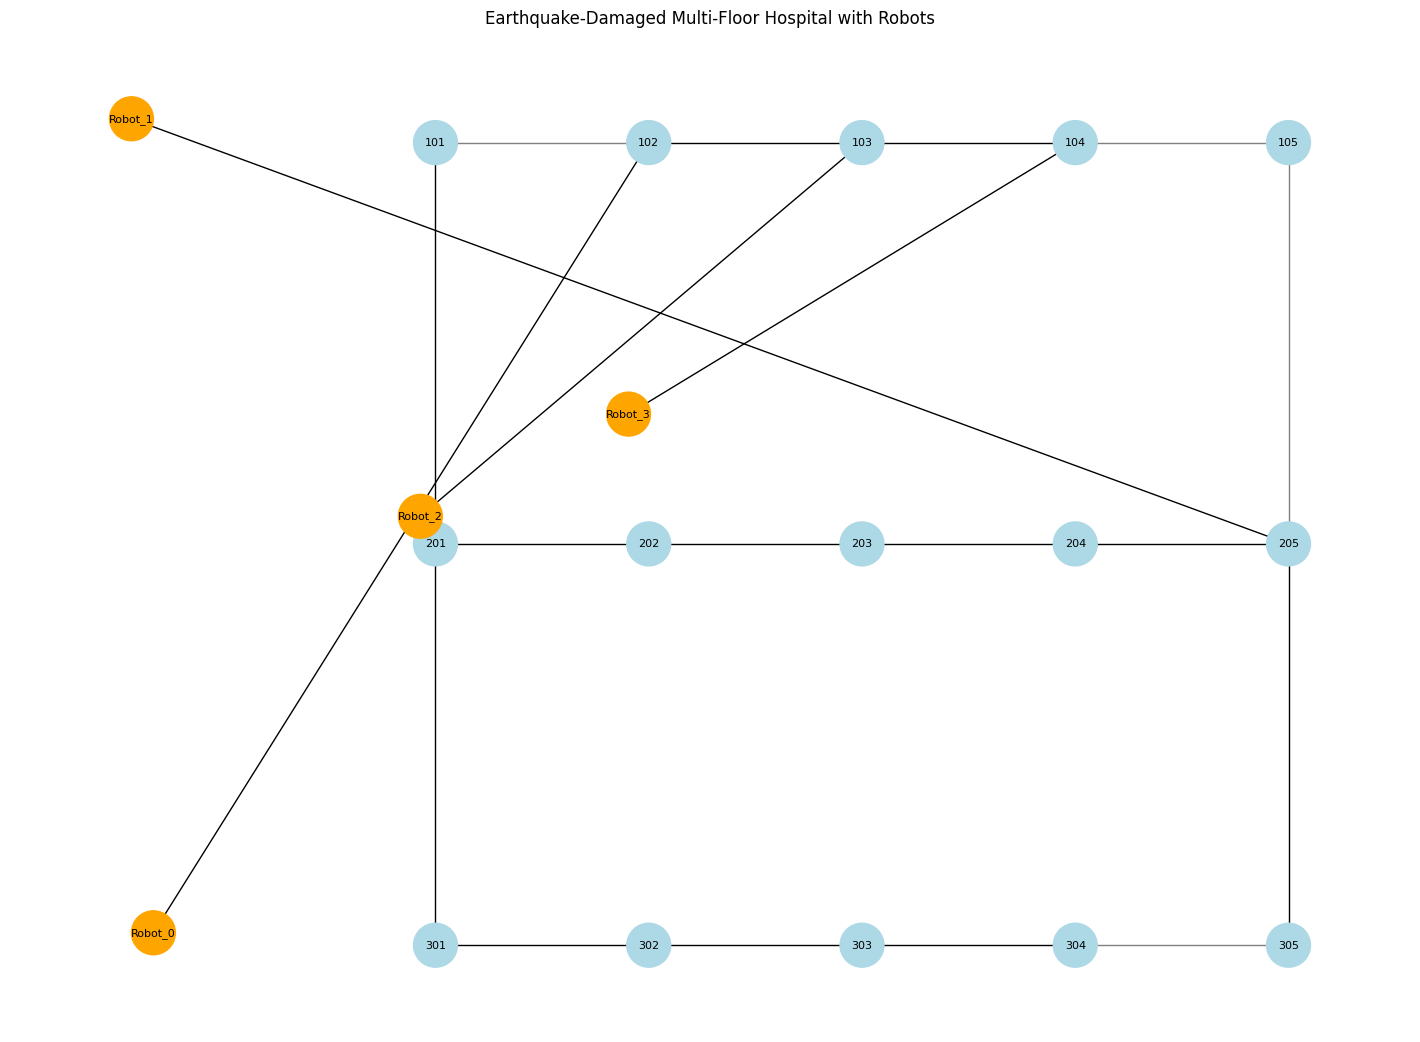

In [7]:
# Choose 2D layout for clarity — space out by room position
pos = {}
for node in G.nodes():
    ntype = G.nodes[node].get("type")

    if ntype == "room":
        floor = G.nodes[node]['floor']
        room_num = int(node) % 100  # offset within floor
        pos[node] = (room_num, -floor)
    elif ntype == "robot":
        pos[node] = (random.uniform(-2, 2), random.uniform(-4, 1))
    else:
        pos[node] = (random.uniform(-1, 6), random.uniform(-4, 1))

# Color-code nodes by type
def get_node_color(n):
    t = G.nodes[n].get("type")
    if t == "room":
        return "lightblue"
    elif t == "robot":
        return "orange"
    else:
        return "gray"

node_colors = [get_node_color(n) for n in G.nodes()]

# Edge color: blocked = gray, open = black
edge_colors = ["gray" if G[u][v].get("status") == "blocked" else "black" for u, v in G.edges()]

# Draw the graph
plt.figure(figsize=(14, 10))
nx.draw(G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=1000,
        font_size=8)

plt.title("Earthquake-Damaged Multi-Floor Hospital with Robots")
plt.show()


In [180]:
import time
random.seed(time.time())  # Ensure true randomness per run

# 1. Pick robot and its starting room
robot_node = random.choice([n for n in G.nodes if G.nodes[n].get("type") == "robot"])
start_room = [nbr for nbr in G.neighbors(robot_node) if G.nodes[nbr].get("type") == "room"][0]

# 2. Find all urgent, viable rooms
urgent_rooms = [
    n for n in G.nodes
    if G.nodes[n].get("type") == "room"
    and G.nodes[n].get("urgency", 0) >= 0.8
    and G.nodes[n].get("structural_integrity", 1.0) > 0.2
]

# Shuffle urgent room list to guarantee variety
random.shuffle(urgent_rooms)

# 3. Copy the graph and remove blocked paths
G_path = G.copy()
blocked = [(u, v) for u, v in G_path.edges if G_path[u][v].get("status") == "blocked"]
G_path.remove_edges_from(blocked)

# 4. Try to find a path to one of the urgent rooms
path_found = False
attempts = 0
max_attempts = 10

while not path_found and urgent_rooms and attempts < max_attempts:
    goal_room = urgent_rooms.pop()
    try:
        path = nx.shortest_path(G_path, source=start_room, target=goal_room, weight='traversal_time')
        total_time = sum(G_path[path[i]][path[i+1]]['traversal_time'] for i in range(len(path)-1))
        path_found = True
    except nx.NetworkXNoPath:
        attempts += 1

# 5. Output
if path_found:
    print(f"🤖 Robot: {robot_node} starting at {start_room}")
    print(f"🏥 Goal: urgent room {goal_room}")
    print(f"📍 Path: {' → '.join(path)}")
    print(f"⏱️ Total traversal time: {round(total_time, 2)}")
else:
    print("❌ No reachable urgent rooms after multiple attempts.")


🤖 Robot: Robot_3 starting at 104
🏥 Goal: urgent room 102
📍 Path: 104 → 103 → 102
⏱️ Total traversal time: 6.68


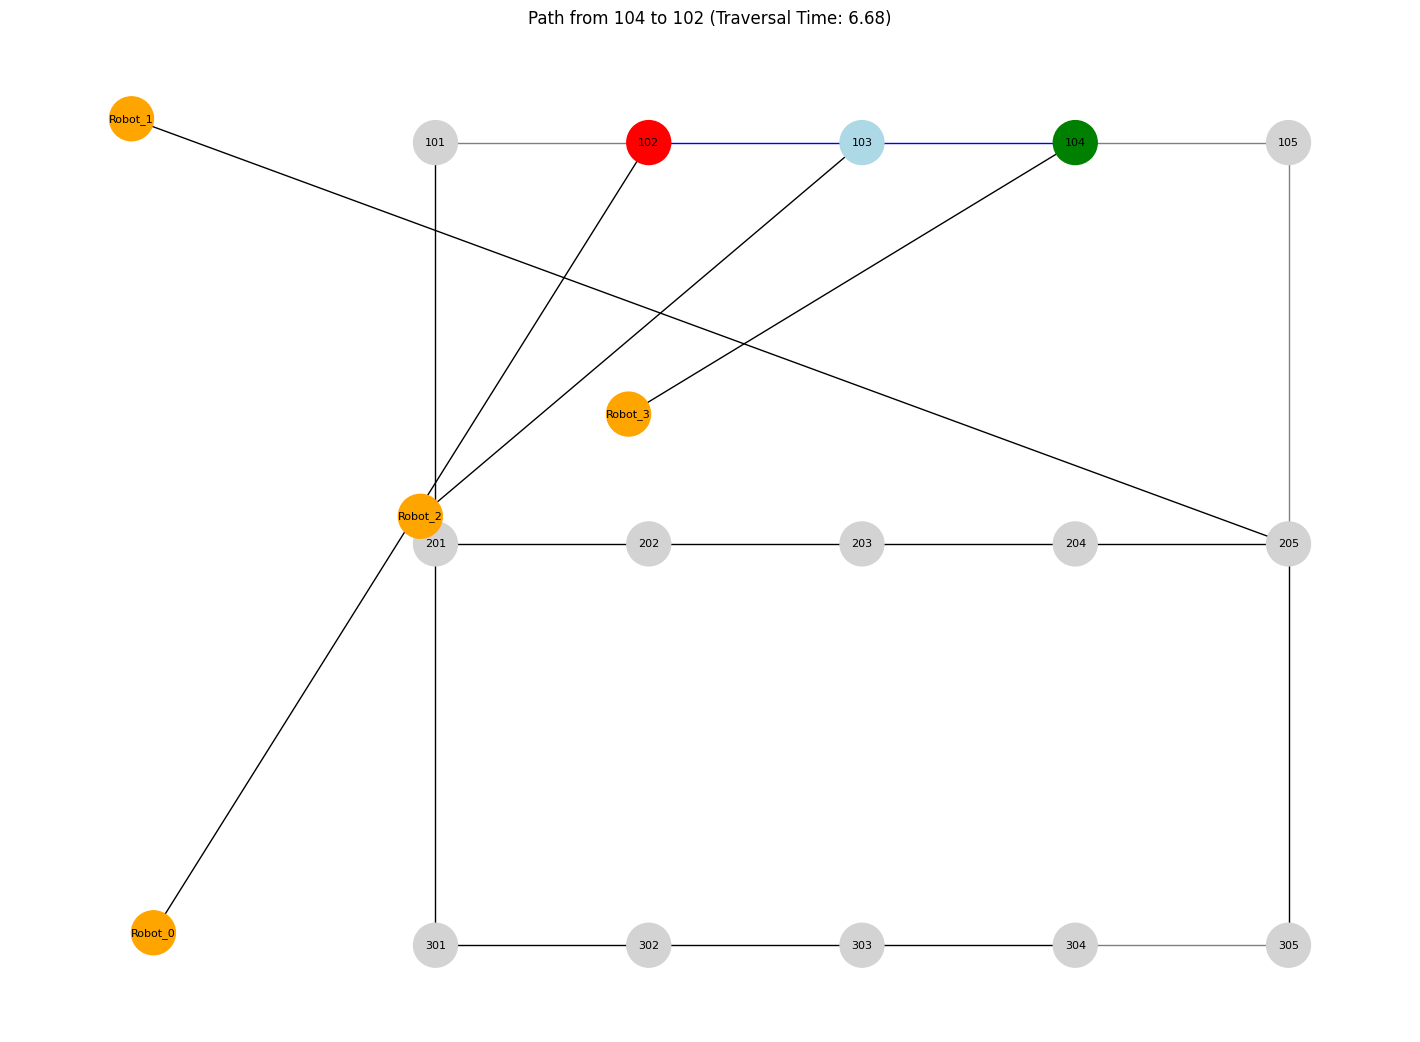

In [181]:
if path_found:
    # Node color map: highlight start, goal, and path
    node_colors = []
    for node in G.nodes():
        if node == start_room:
            node_colors.append('green')  # starting point
        elif node == goal_room:
            node_colors.append('red')    # goal
        elif node in path:
            node_colors.append('lightblue')  # on the path
        elif G.nodes[node].get('type') == 'robot':
            node_colors.append('orange')  # robot
        else:
            node_colors.append('lightgray')

    # Edge color: blue if on path, gray if blocked, black if normal
    edge_colors = []
    for u, v in G.edges():
        if (u in path and v in path) and abs(path.index(u) - path.index(v)) == 1:
            edge_colors.append('blue')
        elif G[u][v].get('status') == 'blocked':
            edge_colors.append('gray')
        else:
            edge_colors.append('black')

    # Draw it
    plt.figure(figsize=(14, 10))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors,
            node_size=1000, font_size=8)
    plt.title(f"Path from {start_room} to {goal_room} (Traversal Time: {round(total_time, 2)})")
    plt.show()
else:
    print("No path to visualize.")


In [182]:
if path_found:
    robot_sensor_quality = G.nodes[robot_node]['sensor_reliability']
    print(f"\n🔍 Robot sensor reliability: {robot_sensor_quality}")

    for room in path:
        if G.nodes[room].get("type") != "room":
            continue

        current_trust = G.nodes[room].get("trust_level", 0.5)

        if robot_sensor_quality >= 0.85:
            # High quality sensor → increase trust
            G.nodes[room]['trust_level'] = min(1.0, current_trust + 0.1)
            status = "↑ Increased trust"
        elif robot_sensor_quality <= 0.65:
            # Low quality → decrease trust (possible misinformation)
            G.nodes[room]['trust_level'] = max(0.0, current_trust - 0.1)
            status = "↓ Decreased trust"
        else:
            # Medium quality → slight nudge toward 0.8 (neutral confidence)
            if current_trust < 0.8:
                G.nodes[room]['trust_level'] += 0.02
            elif current_trust > 0.8:
                G.nodes[room]['trust_level'] -= 0.02
            status = "↔ Stabilizing trust"

        new_trust = G.nodes[room]['trust_level']
        print(f"Room {room}: {status} → {round(new_trust, 2)}")



🔍 Robot sensor reliability: 0.88
Room 104: ↑ Increased trust → 0.6
Room 103: ↑ Increased trust → 0.6
Room 102: ↑ Increased trust → 0.6


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


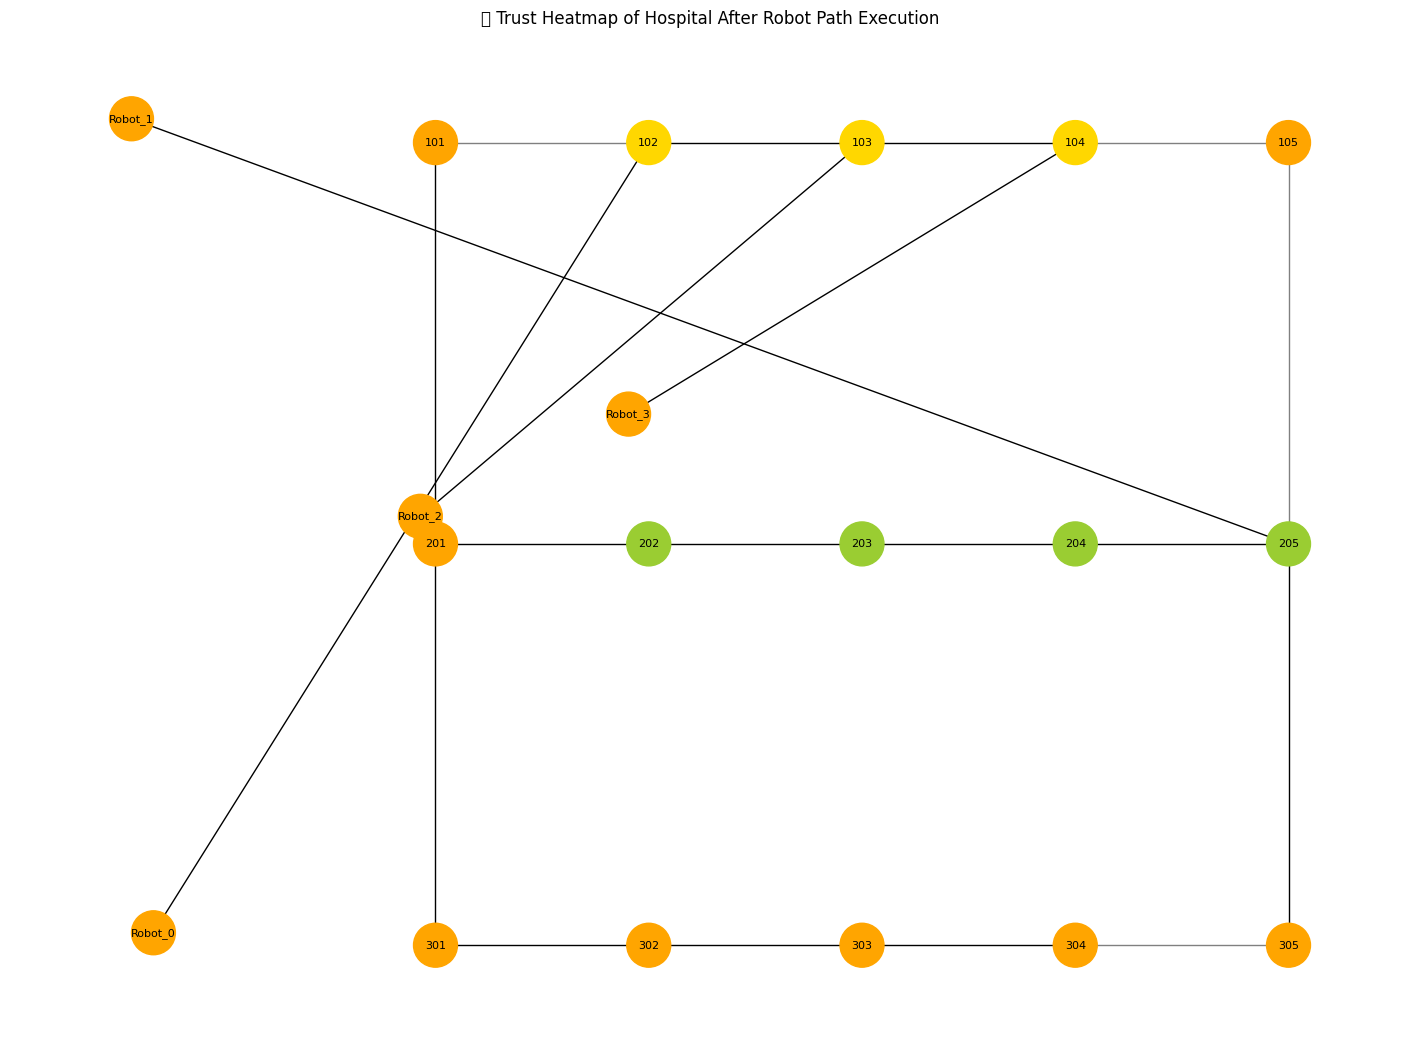

In [183]:
# Function to map trust level → color
def trust_to_color(trust):
    if trust >= 0.9:
        return 'green'
    elif trust >= 0.75:
        return 'yellowgreen'
    elif trust >= 0.6:
        return 'gold'
    elif trust >= 0.4:
        return 'orange'
    else:
        return 'red'

# Assign colors
node_colors = []
for node in G.nodes():
    if G.nodes[node].get("type") == "room":
        trust = G.nodes[node].get("trust_level", 0.5)
        node_colors.append(trust_to_color(trust))
    elif G.nodes[node].get("type") == "robot":
        node_colors.append('orange')
    else:
        node_colors.append('lightgray')

# Edge colors
edge_colors = [
    'gray' if G[u][v].get('status') == 'blocked' else 'black'
    for u, v in G.edges()
]

# Draw the graph
plt.figure(figsize=(14, 10))
nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors,
        node_size=1000, font_size=8)
plt.title("📊 Trust Heatmap of Hospital After Robot Path Execution")
plt.show()
